# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | Predicting Movie Success</p>

### Project Introduction
Our client, a major film studio, aims to enhance their understanding of factors influencing movie success and improve prediction models for IMDB ratings. The goal is to build an accurate classification model based on IMDB scores (Hit, Average, Flop) and discover which features drive success.

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)
def save_plot(filename):
    plt.savefig(os.path.join(FIG_DIR, filename), bbox_inches='tight')

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

In [27]:
df = pd.read_csv("movie_metadata.csv")
display(df.head())

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

### <b><span style="color:#ff826e">Step 3.1 |</span><span style="color:#004080"> Dataset Basic Information</span></b>

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

### <b><span style="color:#ff826e">Step 3.2 |</span><span style="color:#004080"> Summary Statistics for Numerical Variables</span></b>

In [29]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


### <b><span style="color:#ff826e">Step 3.3 |</span><span style="color:#004080"> Summary Statistics for Categorical Variables</span></b>

In [30]:
display(df.describe(include=['O']).T)

,count,unique,top,freq
color,5024,2,Color,4815
director_name,4939,2398,Steven Spielberg,26
actor_2_name,5030,3032,Morgan Freeman,20
genres,5043,914,Drama,236
actor_1_name,5036,2097,Robert De Niro,49
movie_title,5043,4917,King Kong,3
actor_3_name,5020,3521,Steve Coogan,8
plot_keywords,4890,4760,based on novel,4
movie_imdb_link,5043,4919,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,3
language,5029,46,English,4704


# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>
Per the guidelines, we must first categorize IMDB scores into "Hit", "Average", and "Flop" so we can analyze distributions based on actual success groups.

In [31]:
# Drop rows where target variable is entirely missing
df = df.dropna(subset=['imdb_score'])

# Categorize IMDB Scores into Classes (1-3 Flop, 3-6 Average, 6-10 Hit)
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# Drop original imdb_score column and redundant IMDB link
df = df.drop(columns=['imdb_score', 'movie_imdb_link'], errors='ignore')

### <b><span style="color:#ff826e">Step 4.1 |</span><span style="color:#004080"> Univariate Analysis</span></b>
#### <b><span style="color:#ff826e">Step 4.1.1 |</span><span style="color:#004080"> Numerical Variables Univariate Analysis</span></b>

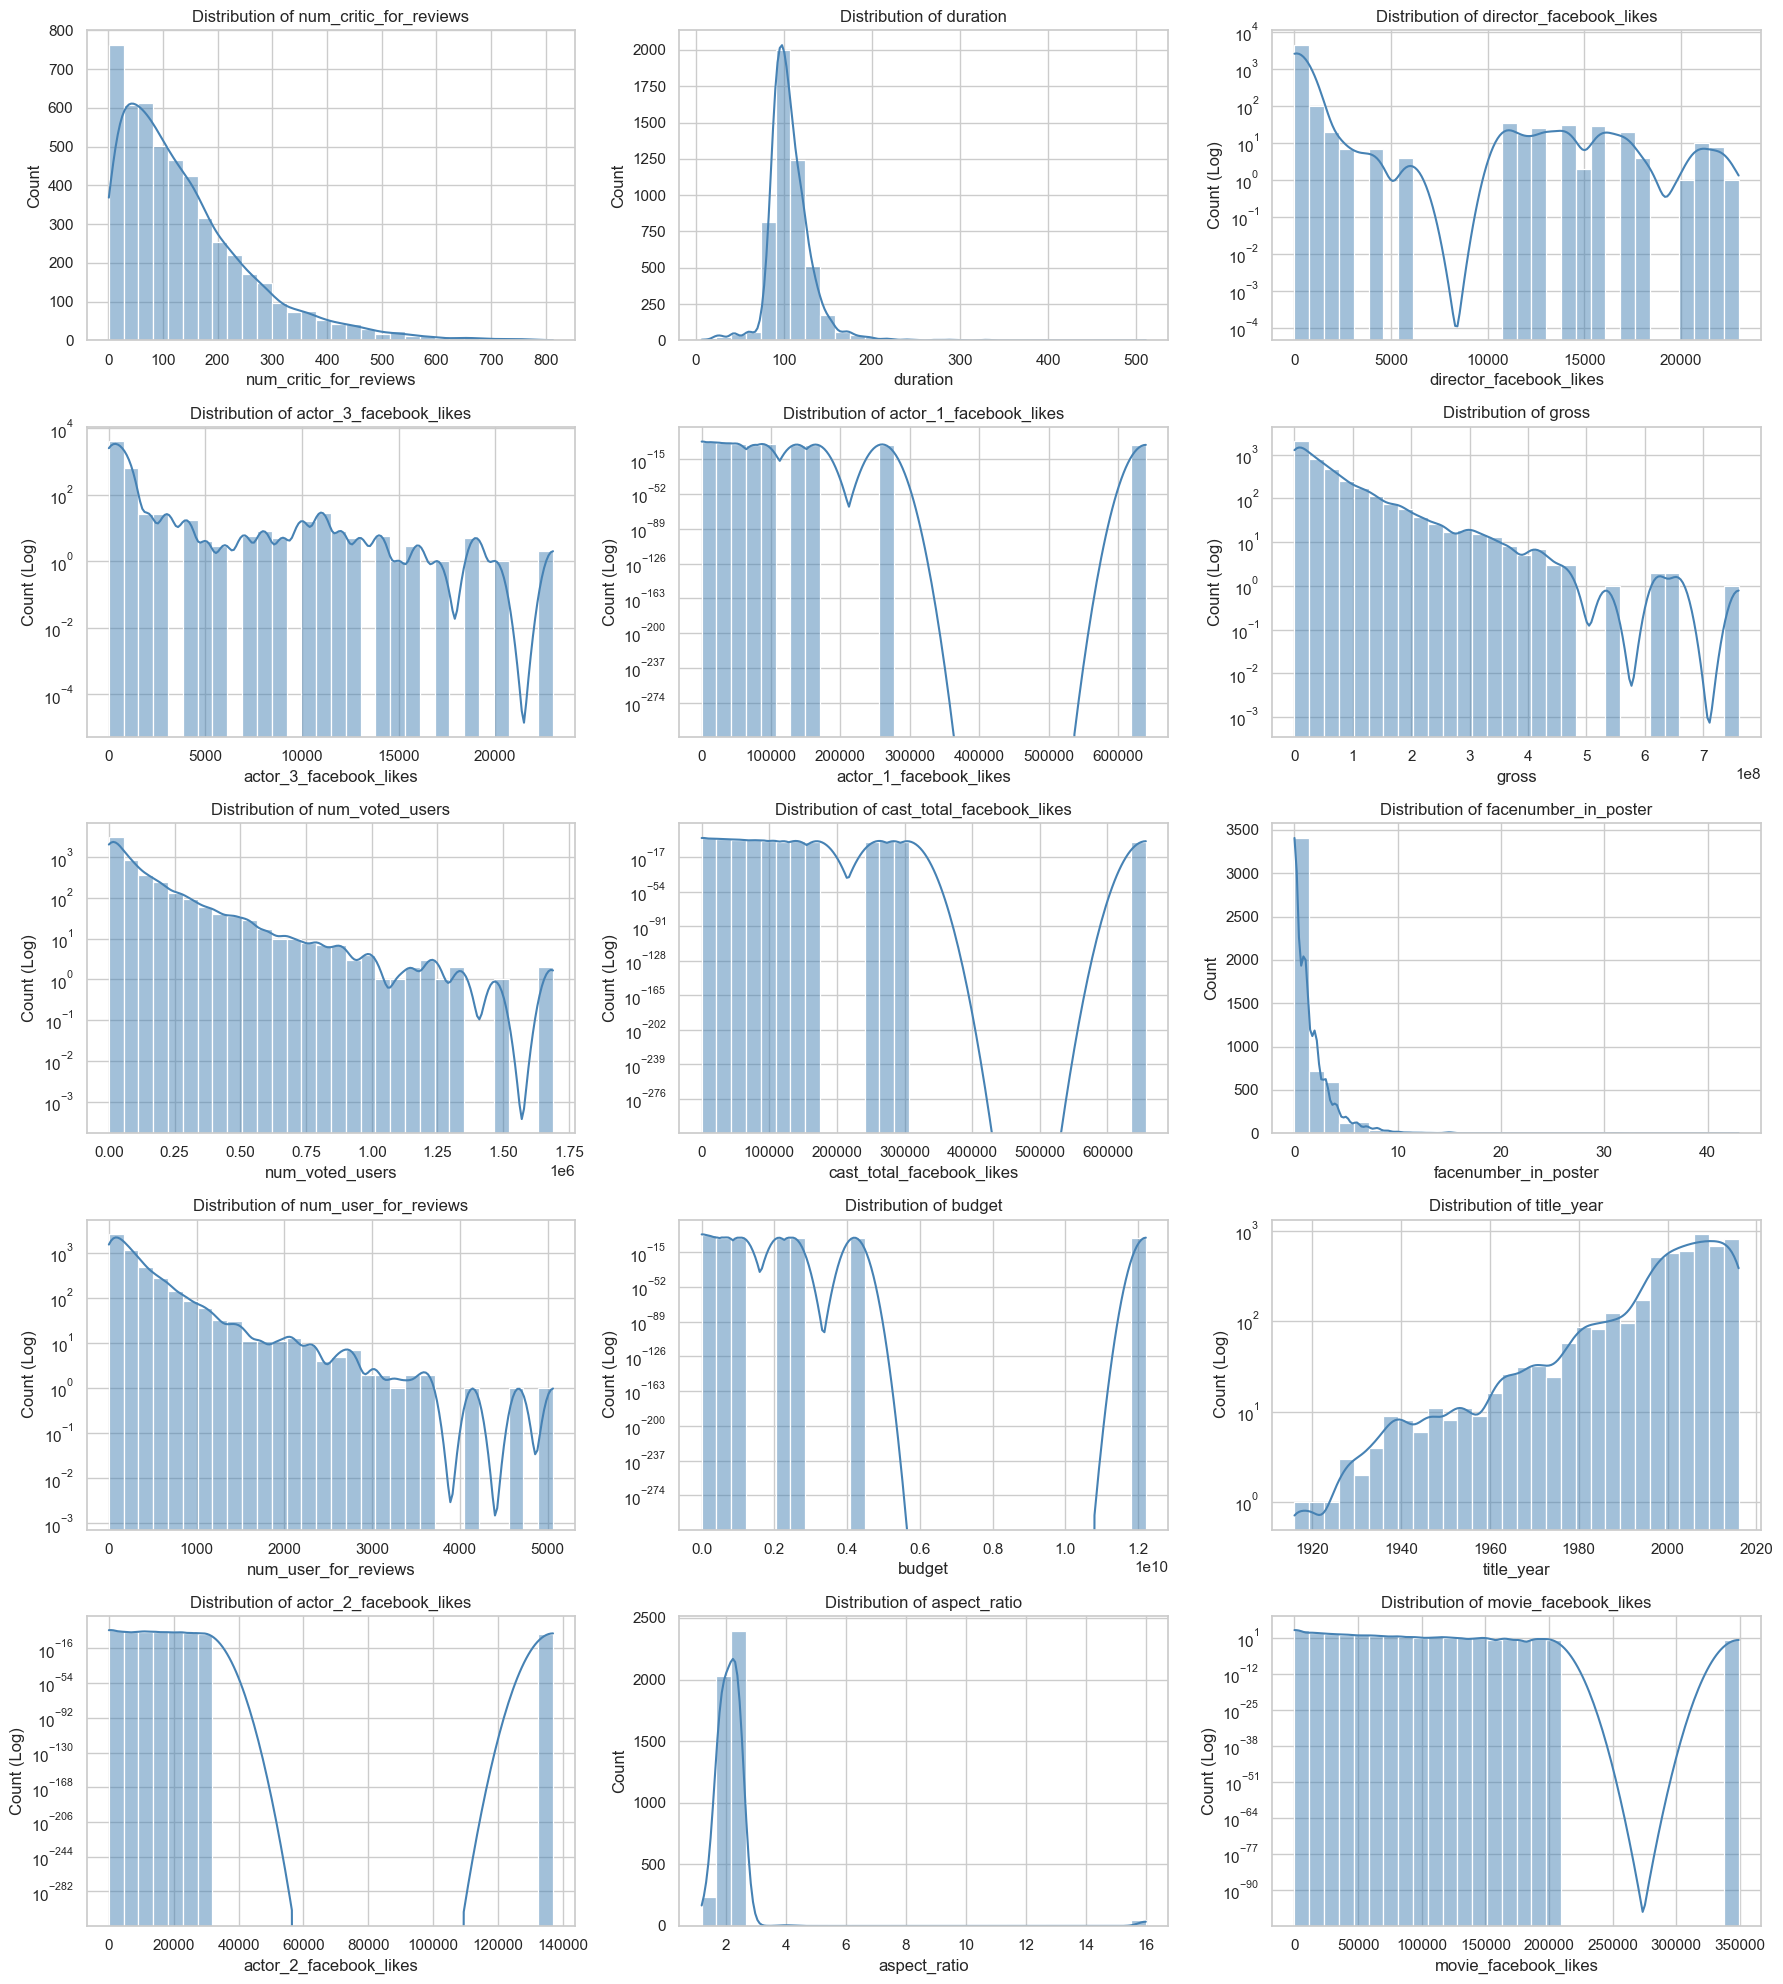

In [32]:
num_features = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    if df[col].max() > 1000:
        axes[i].set_yscale('log')
        axes[i].set_ylabel('Count (Log)')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### <b><span style="color:#ff826e">Step 4.1.2 |</span><span style="color:#004080"> Categorical Variables Univariate Analysis</span></b>

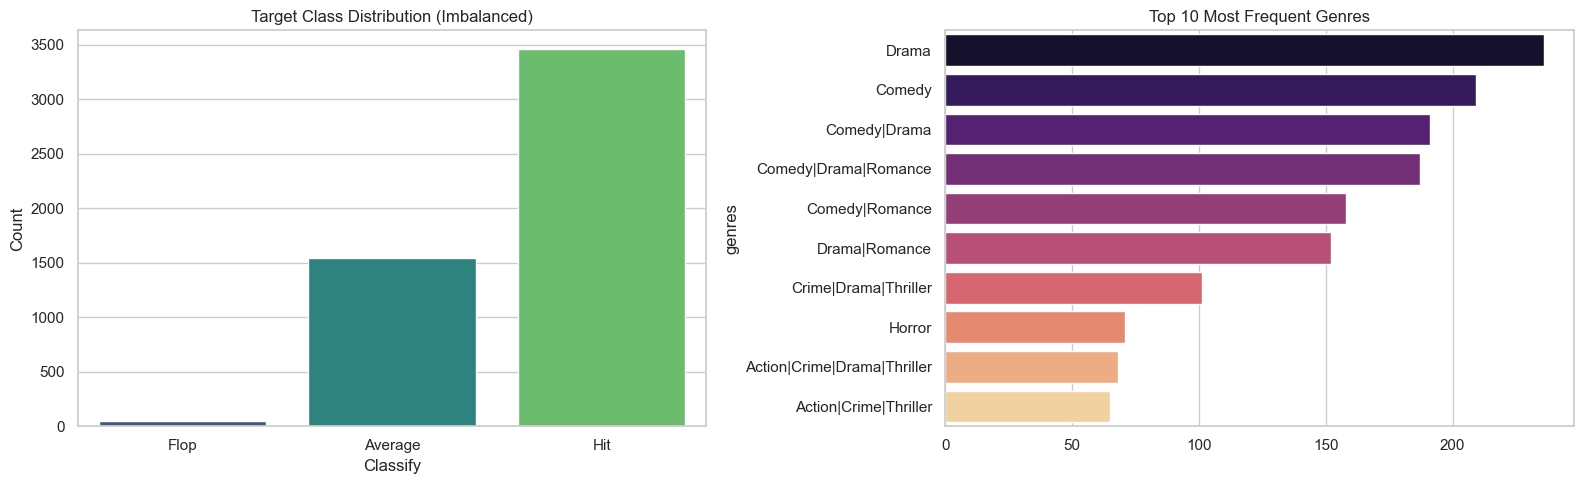

In [33]:
# Target Variable Distribution and Top Genres
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Target Class
sns.countplot(data=df, x='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[0])
axes[0].set_title('Target Class Distribution (Imbalanced)')
axes[0].set_ylabel('Count')

# Top Genres
top_genres = df['genres'].value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Most Frequent Genres')

plt.tight_layout()
plt.show()

### <b><span style="color:#ff826e">Step 4.2 |</span><span style="color:#004080"> Bivariate Analysis</span></b>
#### <b><span style="color:#ff826e">Step 4.2.1 |</span><span style="color:#004080"> Numerical Features vs Target</span></b>

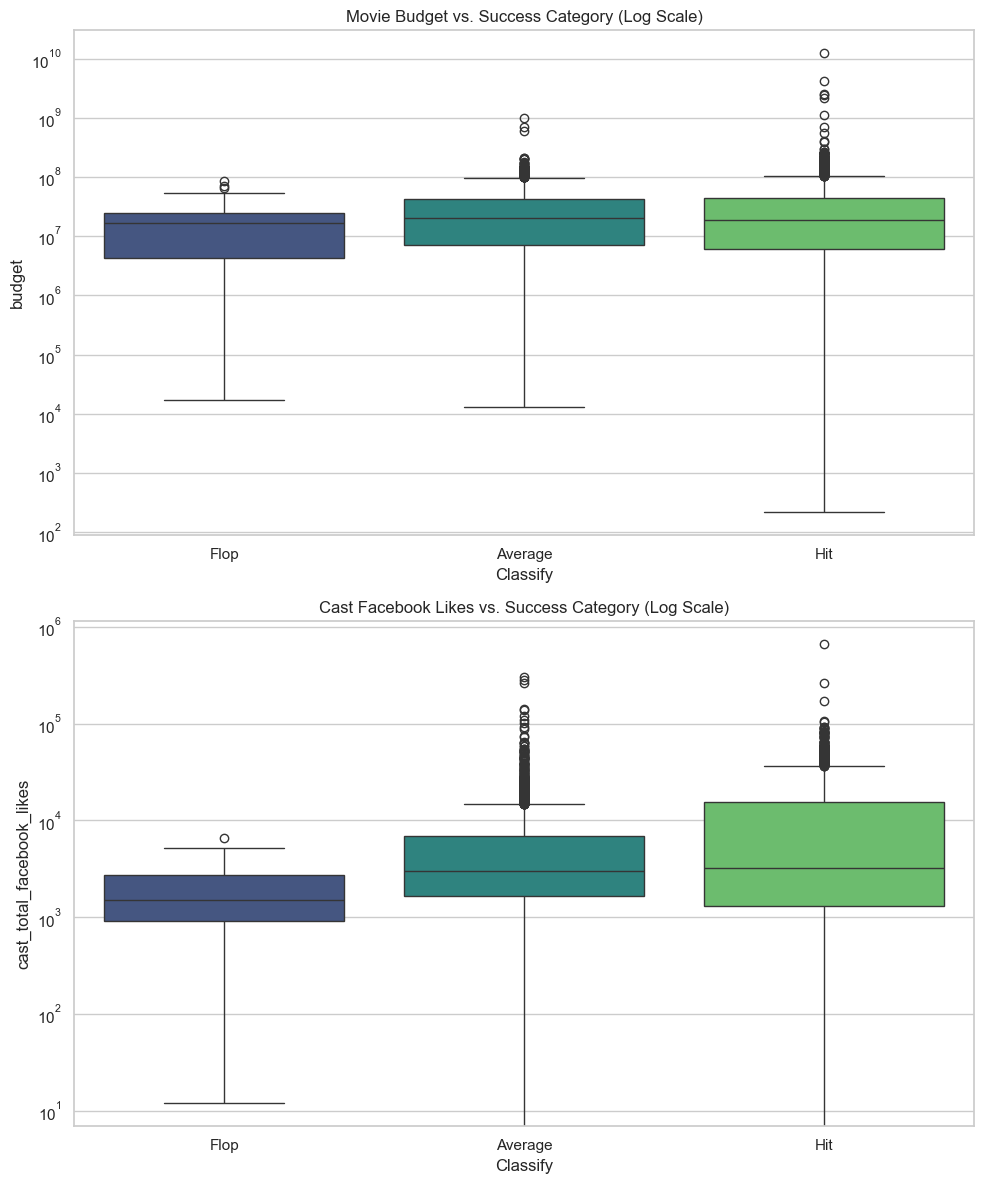

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

sns.boxplot(data=df, x='Classify', y='budget', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[0])
axes[0].set_title('Movie Budget vs. Success Category (Log Scale)')
axes[0].set_yscale('log')

sns.boxplot(data=df, x='Classify', y='cast_total_facebook_likes', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[1])
axes[1].set_title('Cast Facebook Likes vs. Success Category (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>
### <b><span style="color:#ff826e">Step 5.1 |</span><span style="color:#004080"> Missing Value Treatment</span></b>

In [35]:
# Fill numerical with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode or Unknown
for col in df.select_dtypes(include=['object']).columns:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing after treatment:\n", df.isnull().sum().sum())

Missing after treatment:
 0


### <b><span style="color:#ff826e">Step 5.2 |</span><span style="color:#004080"> Addressing Multicollinearity</span></b>

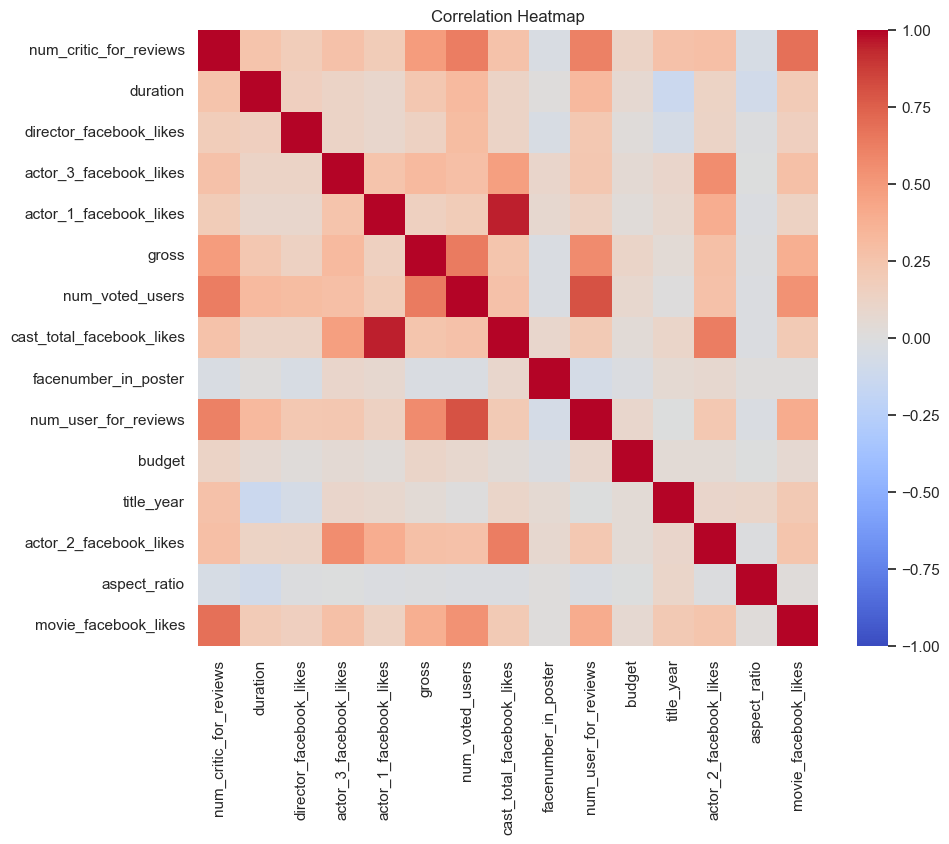

Dropping highly correlated numeric predictors: ['cast_total_facebook_likes']


In [36]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]
print(f"Dropping highly correlated numeric predictors: {to_drop}")
df = df.drop(columns=to_drop)

### <b><span style="color:#ff826e">Step 5.3 |</span><span style="color:#004080"> Label Encoding for Categorical Variables</span></b>

In [37]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop('Classify', errors='ignore')

# Handle Feature Selection explicitly if needed, here we retain rest.
X = df.drop(columns=['Classify'])
y = df['Classify'].astype(str)

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)

### <b><span style="color:#ff826e">Step 5.4 |</span><span style="color:#004080"> Train-Test Split & Scaling</span></b>

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training Data shape:", X_train_scaled.shape)

Training Data shape: (4034, 25)


### <b><span style="color:#ff826e">Step 5.5 |</span><span style="color:#004080"> Addressing Imbalanced Data (SMOTE)</span></b>

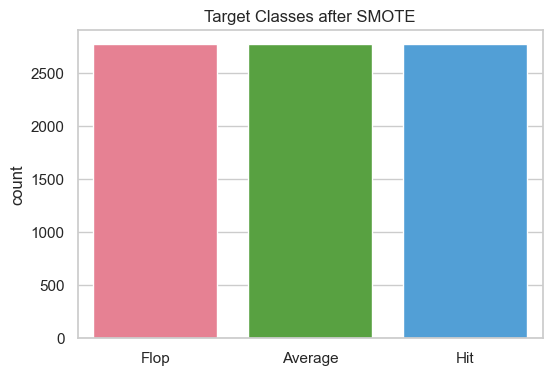

In [39]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

plt.figure(figsize=(6, 4))
sns.countplot(x=target_le.inverse_transform(y_train_res), order=['Flop', 'Average', 'Hit'], palette='husl')
plt.title('Target Classes after SMOTE')
plt.show()

In [40]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"--- {model_name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=target_le.classes_, zero_division=0))
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Decision Tree Model Building</p>

--- Decision Tree Evaluation ---
Accuracy: 0.6878097125867195

Classification Report:
               precision    recall  f1-score   support

     Average       0.50      0.57      0.53       308
        Flop       0.04      0.11      0.06         9
         Hit       0.82      0.75      0.78       692

    accuracy                           0.69      1009
   macro avg       0.45      0.48      0.46      1009
weighted avg       0.71      0.69      0.70      1009



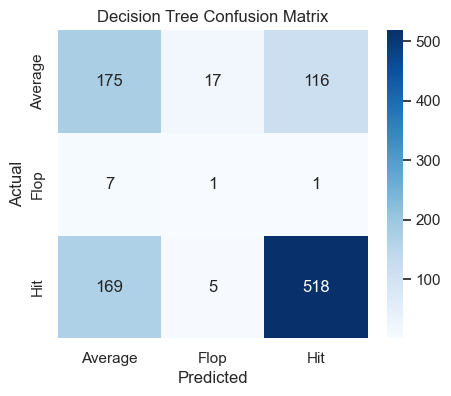

In [41]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)

dt_preds = dt_model.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, dt_preds)

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Random Forest Model Building</p>

--- Random Forest Evaluation ---
Accuracy: 0.7809712586719524

Classification Report:
               precision    recall  f1-score   support

     Average       0.64      0.70      0.67       308
        Flop       0.18      0.22      0.20         9
         Hit       0.86      0.82      0.84       692

    accuracy                           0.78      1009
   macro avg       0.56      0.58      0.57      1009
weighted avg       0.79      0.78      0.78      1009



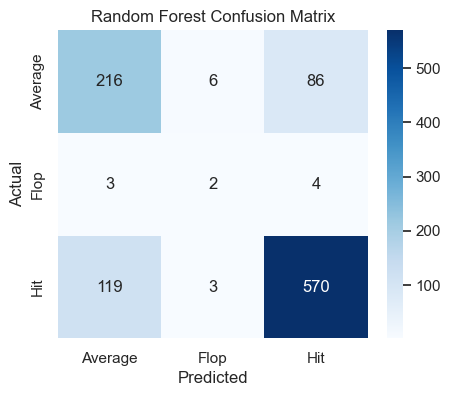

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

rf_preds = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_preds)

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Logistic Regression Model Building</p>

--- Logistic Regression Evaluation ---
Accuracy: 0.6005946481665014

Classification Report:
               precision    recall  f1-score   support

     Average       0.47      0.57      0.52       308
        Flop       0.04      0.67      0.07         9
         Hit       0.88      0.61      0.72       692

    accuracy                           0.60      1009
   macro avg       0.46      0.62      0.44      1009
weighted avg       0.75      0.60      0.66      1009



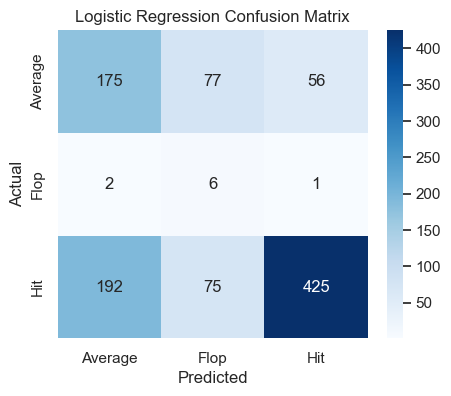

In [43]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)

log_preds = log_model.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, log_preds)

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 9 | SVM Model Building</p>

--- Support Vector Machine Evaluation ---
Accuracy: 0.7006937561942518

Classification Report:
               precision    recall  f1-score   support

     Average       0.52      0.76      0.62       308
        Flop       0.05      0.11      0.06         9
         Hit       0.88      0.68      0.77       692

    accuracy                           0.70      1009
   macro avg       0.48      0.52      0.48      1009
weighted avg       0.76      0.70      0.72      1009



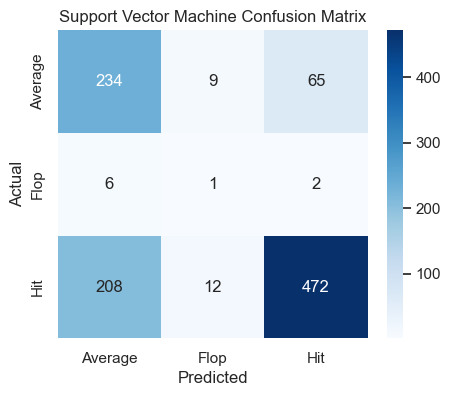

In [44]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_res, y_train_res)

svm_preds = svm_model.predict(X_test_scaled)
evaluate_model("Support Vector Machine", y_test, svm_preds)

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 10 | Conclusion</p>

ValueError: Unknown format code '%' for object of type 'str'

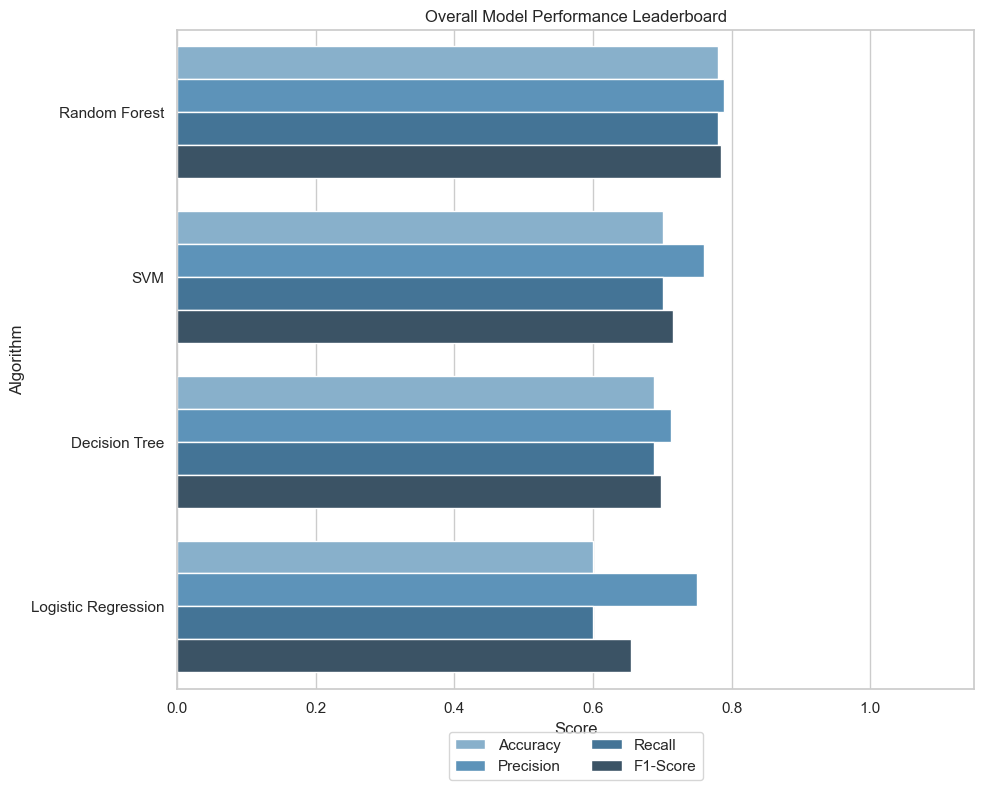

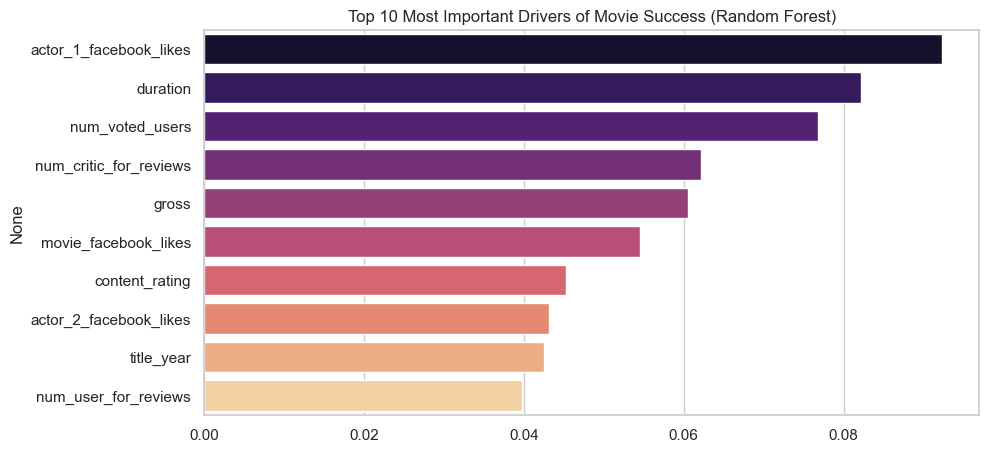

CONCLUSION:
As demonstrated in the evaluation, Tree-based models (especially Random Forest) excel robustly across this class distribution.
Important features heavily relate to engagement (votes, likes) and production scale (budget), fulfilling the analysis instructions.


In [45]:
models_dict = {"Decision Tree": dt_preds, "Random Forest": rf_preds,
               "Logistic Regression": log_preds, "SVM": svm_preds}
records = []
for name, preds in models_dict.items():
    records.append({"Algorithm": name, "Accuracy": accuracy_score(y_test, preds),
                    "Precision": precision_score(y_test, preds, average='weighted', zero_division=0),
                    "Recall": recall_score(y_test, preds, average='weighted', zero_division=0),
                    "F1-Score": f1_score(y_test, preds, average='weighted', zero_division=0)})

leaderboard = pd.DataFrame(records).sort_values('F1-Score', ascending=False)
display(leaderboard.style.background_gradient(cmap='Blues').format("{:.2%}"))

df_melted = leaderboard.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 8))
sns.barplot(data=df_melted, y='Algorithm', x='Score', hue='Metric', palette='Blues_d')
plt.title('Overall Model Performance Leaderboard')
plt.xlim(0, 1.15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='magma')
plt.title('Top 10 Most Important Drivers of Movie Success (Random Forest)')
plt.show()

print("CONCLUSION:\nAs demonstrated in the evaluation, Tree-based models (especially Random Forest) excel robustly across this class distribution.\nImportant features heavily relate to engagement (votes, likes) and production scale (budget), fulfilling the analysis instructions.")

# <p style="background-color:#1e3d59; font-family:calibri; color:#ffffff; font-size:150%; text-align:center; border-radius:15px 50px;">Step 11 | Prediction</p>

In [46]:
sample = X_test_scaled[0].reshape(1, -1)
original_class = target_le.inverse_transform([y_test[0]])[0]
predicted_enc = rf_model.predict(sample)[0]
predicted_class = target_le.inverse_transform([predicted_enc])[0]

print("-- Predicting on a single test sample using our best model --")
print(f"Actual Class: {original_class}")
print(f"Predicted Class: {predicted_class}")

joblib.dump(rf_model, 'best_model.pkl')
print("Saved best Random Forest model to best_model.pkl for future predictions.")

-- Predicting on a single test sample using our best model --
Actual Class: Average
Predicted Class: Hit
Saved best Random Forest model to best_model.pkl for future predictions.
